# Image Reward

The introduction and implementations of Image Reward.

Written by yuanjk0921@outlook.com

Updated on March 6, 2025

**Contents**
- Image Reward
- PyTorch Implementations

**References**

- [**ImageReward: Learning and Evaluating Human Preferences for Text-to-Image Generation** *(NeurIPS 2023)*](https://arxiv.org/pdf/2304.05977): The paper which proposes the Image Reward.

## Image Reward

It trains BLIP on 137K human preference image pairs for image generation and use it to tune diffusion models by Reward Feedback Learning (ReFL).

## PyTorch Implementations

In [ ]:
## --------------------------------------------------------------------------------
## Load model
## --------------------------------------------------------------------------------

# Install package: 'python3 -m pip install image-reward'

import ImageReward as RM
cache_dir = "ImageReward/"
model = RM.load("ImageReward-v1.0", device="cuda", download_root=cache_dir)

In [ ]:
## --------------------------------------------------------------------------------
## Prepare data
## --------------------------------------------------------------------------------
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class ImageDataset(Dataset):
    def __init__(self, image_paths, prompts, image_size):
        self.image_paths = image_paths
        self.prompts = prompts

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        file_path = self.image_paths[index]
        image = []
        prompt = self.prompts[index]
        return image, prompt, file_path
        return image, prompt, file_path
    
# remove
image_paths = ["0.png"] * 6
image_paths += ["1.png"] * 6
image_paths = image_paths + ["random_noise.png"] * 2

## Save a noise image
noise = np.random.randint(0, 256, (3, 224, 224), dtype=np.uint8)
image = Image.fromarray(noise, mode='RGB')
image.save("random_noise.png")

prompts = [
    "a bench and a bird",
    "a bench and a bowl",
    "a bowl and a bench",
    "a blue bench and a green bowl",
    "a green bench and a blue bowl",
    "a green bench and a green bowl",
    "two bears",
    "a bear and a bear",
    "a bear and a beer",
    "two bears are reading books",
    "two bears are reading some books",
    "three bears are reading books",
    "two bears",
    "a bear and a bear"
]

dataset = ImageDataset(image_paths=image_paths, prompts=prompts, image_size=256)
dataloader = DataLoader(dataset=dataset, batch_size=6, shuffle=False)

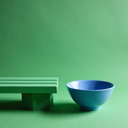

=> prompt: a bench and a bird, Image Reward Score: -2.2556676864624023
=> prompt: a bench and a bowl, Image Reward Score: 1.3627185821533203
=> prompt: a bowl and a bench, Image Reward Score: 1.7412118911743164
=> prompt: a blue bench and a green bowl, Image Reward Score: 0.10545250028371811
=> prompt: a green bench and a blue bowl, Image Reward Score: 1.5103744268417358
=> prompt: a green bench and a green bowl, Image Reward Score: 0.3006550371646881


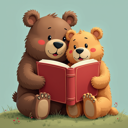

=> prompt: two bears, Image Reward Score: -0.5952475070953369
=> prompt: a bear and a bear, Image Reward Score: 0.26699504256248474
=> prompt: a bear and a beer, Image Reward Score: -2.036942958831787
=> prompt: two bears are reading books, Image Reward Score: 1.7299389839172363
=> prompt: two bears are reading some books, Image Reward Score: 1.582936406135559
=> prompt: three bears are reading books, Image Reward Score: 0.9099398255348206


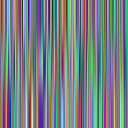

=> prompt: two bears, Image Reward Score: -2.279113292694092
=> prompt: a bear and a bear, Image Reward Score: -2.281336545944214


In [3]:
## --------------------------------------------------------------------------------
## Evaluate
## --------------------------------------------------------------------------------
import torch.nn.functional as F

for idx, (images, prompts, file_paths) in enumerate(dataloader):
    scores = []
    for i in range(len(file_paths)):
        image = Image.open(file_paths[i])
        s = model.score(prompts[i], image)
        scores.append(s)
                    
    ## Show results
    # image = Image.open(file_paths[0]).resize((128, 128))
    display(image.resize((128, 128)))
    for prompt, score in zip(prompts, scores):
        print(f"=> prompt: {prompt}, Image Reward Score: {score}")

**Observations:**

- It shows great capability in identifying <font color=red>semantic alignment</font>.